Loading existing grid from: ../../ExtractedDatasets/ClimateFeatures\grid_0p1.gpkg
Grid loaded: 23322 cells.
Loading combined land cover polygons...


c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Several features with id = 1 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


Land cover columns: Index(['id', 'gridcode', 'area', 'lcccode', 'geometry'], dtype='object')
Performing spatial join (sampling land cover at grid centroids)...


C:\Users\moous\AppData\Local\Temp\ipykernel_28700\1166111441.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids['geometry'] = centroids.geometry.centroid


Extracted 23322 rows.
   cell_id        id  gridcode          area lcccode
0        0  111056.0     201.0  3.358561e+11    6001
1        1  111056.0     201.0  3.358561e+11    6001
2        2  111056.0     201.0  3.358561e+11    6001
3        3  111056.0     201.0  3.358561e+11    6001
4        4  111056.0     201.0  3.358561e+11    6001



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\

AttributeError: _ARRAY_API not found

✅ Saved grid-aligned land cover to:
 ../../ExtractedDatasets/LandCoverDataset/landcover_0p1_grid.parquet


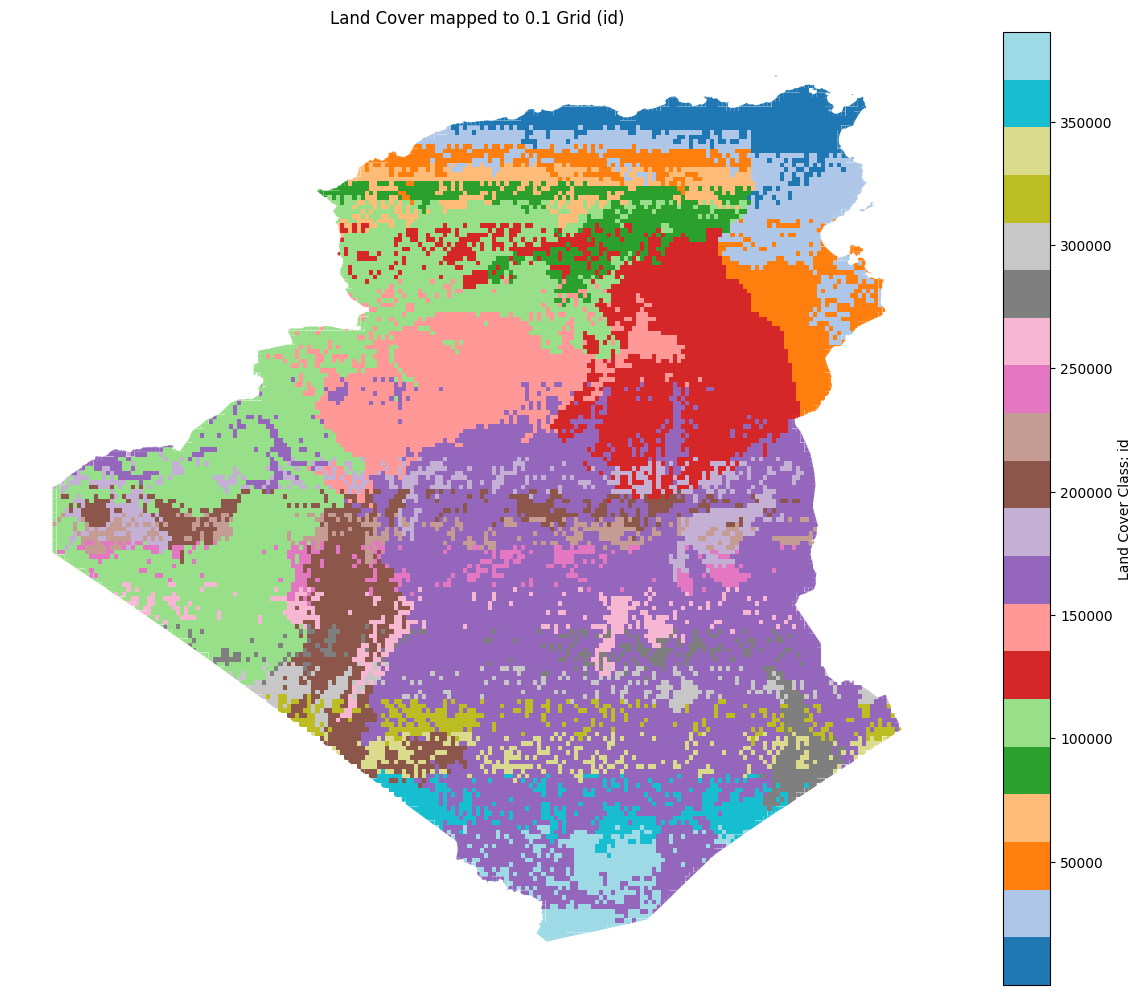

In [4]:
'''
Why this approach?
Consistency (build_grid_from_aoi): By using the exact same grid generation code (or loading the specific GPKG file your climate script made), we guarantee that cell_id #5 in the climate file corresponds exactly to cell_id #5 in this land cover file.

Centroids vs. Intersection:

Intersection: Would calculate the % of Forest vs. Urban in every 11km cell. This is accurate but computationally heavy and complex to store (one row per cell per class).

Centroids (Selected Method): This matches your climate methodology. It simply asks: "What land cover is at the exact center of this grid cell?" This is standard for dominating a grid with categorical data and is much faster.

'''
# %%
import geopandas as gpd
import pandas as pd
import numpy as np
import os
from pathlib import Path
from shapely.geometry import box
from dotenv import load_dotenv
import matplotlib.pyplot as plt

# %%
# ------- 1. CONFIG & ENVIRONMENT -------
def load_environment():
    """Load environment variables and return them as a dictionary."""
    # Adjust path if necessary based on where you run this notebook
    load_dotenv(Path("../utils/.env")) 
    env_vars = {
        "EXTRACTEDDATASET_FOLDER": os.getenv("EXTRACTEDDATASET_FOLDER"),
        "EXTRACTEDLANDCOVER_FOLDER": os.getenv("EXTRACTEDLANDCOVER_FOLDER"),
        "GeoBoundaries": os.getenv("GeoBoundaries"),
        "EXTRACTEDGEOBOUNDARIES_FOLDER": os.getenv("EXTRACTEDGEOBOUNDARIES_FOLDER"),
        "EXTRACTED_CLIMATE_FOLDER": os.getenv("EXTRACTEDDATASET_FOLDER") + "/ClimateFeatures" # inferred
    }
    return env_vars

folders = load_environment()

# Input Paths
LANDCOVER_COMBINED = f"{folders['EXTRACTEDLANDCOVER_FOLDER']}/landcover_combined.geojson"
AOI_PATH = r"..\..\ExtractedDatasets\GeoBoundaries\AOI_DZA_TUN\aoi_dza_tun.gpkg" 

# Output Paths
OUT_DIR = folders['EXTRACTEDLANDCOVER_FOLDER']
GRID_PATH = os.path.join(folders['EXTRACTED_CLIMATE_FOLDER'], "grid_0p1.gpkg") # Tries to load the existing climate grid first

# Settings
GRID_RES_DEG = 0.1

# %%
# ------- 2. LOAD OR CREATE THE EXACT SAME GRID -------
# We strictly use the same logic as the climate script to ensure cell_ids match

def build_grid_from_aoi(aoi_path, res_deg=0.1):
    print(f"Building new grid from {aoi_path} with res={res_deg}...")
    aoi = gpd.read_file(aoi_path).to_crs("EPSG:4326")
    w, s, e, n = aoi.total_bounds
    
    # Create ranges
    xs = np.arange(w, e, res_deg)
    ys = np.arange(s, n, res_deg)
    
    # Create cells
    cells = [box(x, y, x + res_deg, y + res_deg) for x in xs for y in ys]
    grid_bbox = gpd.GeoDataFrame(geometry=cells, crs="EPSG:4326")
    
    # Intersect with AOI to keep only relevant cells
    grid = gpd.overlay(grid_bbox, aoi[["geometry"]], how="intersection", keep_geom_type=True)
    grid = grid.reset_index(drop=True).reset_index(names="cell_id")
    return grid

# Try to load existing grid from climate extraction to be 100% sure IDs match
if os.path.exists(GRID_PATH):
    print(f"Loading existing grid from: {GRID_PATH}")
    grid = gpd.read_file(GRID_PATH)
else:
    # Fallback: Rebuild it using the exact same logic
    print("Existing grid not found. Rebuilding to match climate logic...")
    grid = build_grid_from_aoi(AOI_PATH, res_deg=GRID_RES_DEG)

print(f"Grid loaded: {len(grid)} cells.")

# %%
# ------- 3. LOAD LAND COVER DATA -------
print("Loading combined land cover polygons...")
lc_gdf = gpd.read_file(LANDCOVER_COMBINED)

# Ensure CRS matches the grid (EPSG:4326)
if lc_gdf.crs != grid.crs:
    print(f"Reprojecting Land Cover from {lc_gdf.crs} to {grid.crs}...")
    lc_gdf = lc_gdf.to_crs(grid.crs)

# Optional: Clean columns to keep only what's necessary (adjust column names based on your specific shapefile attributes)
# Typically looking for 'gridcode', 'label', 'class', or 'id'
print("Land cover columns:", lc_gdf.columns)
# lc_gdf = lc_gdf[['geometry', 'gridcode', 'class_name']] # Uncomment and adjust if you want to filter columns

# %%
# ------- 4. SAMPLING STRATEGY (SPATIAL JOIN) -------
# The climate script sampled rasters at the centroid. 
# We will do the same: create centroids for the grid and find which polygon they fall into.

# A. Create Centroids
centroids = grid.copy()
centroids['geometry'] = centroids.geometry.centroid

# B. Spatial Join (Point in Polygon)
print("Performing spatial join (sampling land cover at grid centroids)...")
# 'inner' join keeps only centroids that fall INSIDE a land cover polygon
joined = gpd.sjoin(centroids, lc_gdf, how="left", predicate="within")

# %%
# ------- 5. CLEANUP AND SAVE -------

# Select relevant columns. 
# We need 'cell_id' from the grid, and the classification columns from the land cover.
# We drop 'geometry' to save as a tabular dataset (CSV/Parquet) like the climate data.

# Identify columns that came from the landcover dataset (excluding index_right which sjoin adds)
lc_cols = [c for c in joined.columns if c not in ['cell_id', 'geometry', 'index_right']]

final_df = pd.DataFrame(joined[['cell_id'] + lc_cols])

# Handle duplicates? 
# If a centroid falls on the border of two polygons, sjoin might create two rows.
# We drop duplicates to keep one dominant class per cell.
final_df = final_df.drop_duplicates(subset=['cell_id'])

print(f"Extracted {len(final_df)} rows.")
print(final_df.head())

# Save
out_parquet = f"{OUT_DIR}/landcover_0p1_grid.parquet"
out_csv = f"{OUT_DIR}/landcover_0p1_grid.csv"

final_df.to_parquet(out_parquet)
final_df.to_csv(out_csv, index=False)

print(f"✅ Saved grid-aligned land cover to:\n {out_parquet}")

# %%
# %%
# ------- 6. VISUALIZATION CHECK (CORRECTED) -------
import matplotlib.pyplot as plt
import geopandas as gpd

# Assumes final_df and grid are loaded/created
# If you saved the data, you would reload it first:
# grid = gpd.read_file(GRID_PATH)
# final_df = pd.read_parquet(f"{OUT_DIR}/landcover_0p1_grid.parquet") 
# plot_gdf = grid.merge(final_df, on='cell_id', how='left')


# --- Find a suitable column to plot ---
# Check which land cover attribute you want to use. 
# We'll default to the first non-cell_id column from the merged data.
# Note: For categorical data like landcover, it's best to plot the code or the string name.

# Get the list of columns after the merge
merged_cols = plot_gdf.columns.tolist()
# Find the first column that isn't 'cell_id' or 'geometry'
column_to_plot = next((col for col in merged_cols if col not in ['cell_id', 'geometry']), None)


if column_to_plot:
    fig, ax = plt.subplots(figsize=(12, 10)) # Increased size for better legend space
    
    # Corrected Plotting Call:
    # 1. Removed 'bbox_to_anchor' from legend_kwds entirely, as it causes TypeError.
    # 2. Added 'loc="lower left"' as a valid colorbar keyword (optional, for demonstration).
    # 3. Use `ax.set_aspect(1)` to ensure correct map ratio.
    
    plot_gdf.plot(
        column=column_to_plot, 
        ax=ax, 
        cmap='tab20', 
        legend=True,
        # Only use colorbar keywords here
        legend_kwds={
            'label': f'Land Cover Class: {column_to_plot}',
            'orientation': "vertical" 
        }
    )
    
    ax.set_title(f"Land Cover mapped to 0.1 Grid ({column_to_plot})")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

else:
    print("Error: Could not find a column to plot. Check the column names in your final_df.")

In [5]:
import pandas as pd
import os

# --- 1. Define Paths ---
# Re-using the environment variable structure from your previous scripts
# Assuming the Parquet file is in the EXTRACTEDLANDCOVER_FOLDER
from dotenv import load_dotenv
from pathlib import Path

def load_output_path():
    """Load environment variables and return the landcover output path."""
    load_dotenv(Path("../utils/.env")) 
    return os.getenv("EXTRACTEDLANDCOVER_FOLDER")

OUT_DIR = load_output_path()
PARQUET_PATH = f"{OUT_DIR}/landcover_0p1_grid.parquet"

# --- 2. Load and View ---
try:
    # Load the Parquet file
    df = pd.read_parquet(PARQUET_PATH)
    
    print(f"✅ Successfully loaded data from: {PARQUET_PATH}\n")
    print(f"Total rows: {len(df)}")
    print("-" * 30)

    # Display the first few rows
    print("## 📊 Head of the Data:")
    print(df.head())
    print("\n" + "-" * 30)
    
    # Display data types and non-null counts
    print("## 📝 Column Information:")
    df.info()

except FileNotFoundError:
    print(f"❌ Error: File not found at {PARQUET_PATH}. Please check the directory.")
except Exception as e:
    print(f"❌ An error occurred while reading the Parquet file: {e}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\venv\Lib\

AttributeError: _ARRAY_API not found

✅ Successfully loaded data from: ../../ExtractedDatasets/LandCoverDataset/landcover_0p1_grid.parquet

Total rows: 23322
------------------------------
## 📊 Head of the Data:
       cell_id        id  gridcode          area lcccode
index                                                   
0            0  111056.0     201.0  3.358561e+11    6001
1            1  111056.0     201.0  3.358561e+11    6001
2            2  111056.0     201.0  3.358561e+11    6001
3            3  111056.0     201.0  3.358561e+11    6001
4            4  111056.0     201.0  3.358561e+11    6001

------------------------------
## 📝 Column Information:
<class 'pandas.core.frame.DataFrame'>
Index: 23322 entries, 0 to 23321
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   cell_id   23322 non-null  int64  
 1   id        23189 non-null  float64
 2   gridcode  23189 non-null  float64
 3   area      23189 non-null  float64
 4   lcccode   23189 non-null  ob

In [6]:
df['lcccode'].unique()

array(['6001', '0011', '20058', '6004', None, '20049 // 20058', '0010',
       '11498', '0004 // 0003', '21518', '21450', '0003 / 0004',
       '7001 // 8001', '21446 // 21450-121340 / 21454', '21497-121340',
       '21499-121340', '21454 // 21446 // 21450', '6020'], dtype=object)